# Transformaciones a Tiempo-Frecuencia

In [1]:
# Cargar los datos acondicionados
from os import path
import pandas as pd

FILE_PATH = './data/eeg_eye_state_clean.csv'

if not path.exists(FILE_PATH):
    print("El archivo no existe.")
    raise FileNotFoundError(f"El archivo no existe: {FILE_PATH}")
else:
    df = pd.read_csv(FILE_PATH)
    print(f"Los datos ya existen en {FILE_PATH}")

Los datos ya existen en ./data/eeg_eye_state_clean.csv


In [2]:
FS = 128  # Frecuencia de muestreo en Hz
CHANNELS = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']
TARGET_COL = 'eyeDetection' # 0: ojos abiertos, 1: ojos cerrados
display(df.head())

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection,time_sec
0,0.316986,-0.009590,-0.425512,-0.178237,-0.495224,-0.433845,-0.376640,-0.087048,-0.367611,-0.179262,-0.065064,-0.206539,0.295180,0.311013,0,0.000000
1,0.148499,-0.261122,-0.037817,0.000466,-1.889262,-0.402091,-0.311248,-0.504575,-1.656679,-1.487666,-0.371785,-0.286792,0.059751,-0.097425,0,0.007812
2,0.238762,-0.152250,0.258080,0.429076,-2.289343,-0.829962,-0.285056,-0.936115,-1.394767,-1.577026,-0.374962,0.011411,-0.002536,0.072909,0,0.015625
3,0.364437,0.141366,0.320526,0.498608,-1.509634,-0.950962,-0.305308,-1.127057,-0.857161,-0.378913,-0.068893,0.568022,0.115823,0.538945,0,0.023438
4,0.223377,0.102834,-0.028277,0.257562,-0.775032,-0.465011,-0.394211,-1.558909,-1.450010,0.302976,0.184338,0.703293,0.188884,0.642127,0,0.031250


## Transformada de fourier de corto plazo

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft

In [4]:
def apply_stft(series, fs = FS, window_sec = 2, overlap_pct = 0.75):
    n_per_seg = int(window_sec * fs)
    n_overlap = int(n_per_seg * overlap_pct)

    f, t, Zxx = stft(series, fs=fs, window='hann', nperseg=n_per_seg, noverlap=n_overlap)
    psd = np.abs(Zxx)
    
    return f, t, psd

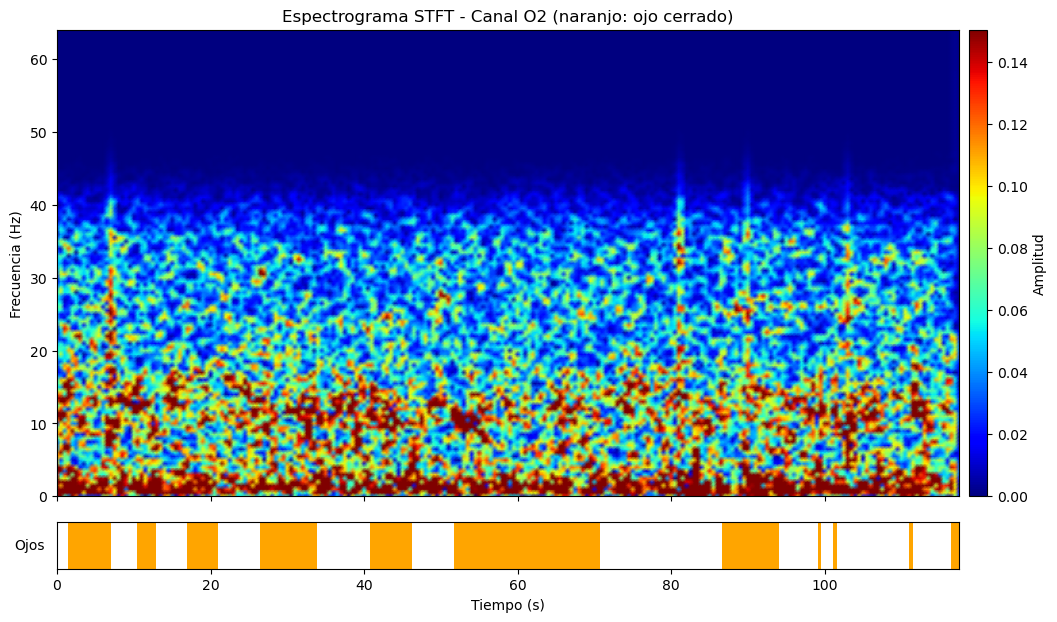

In [5]:
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable

target = 'O2'
f, t, psd = apply_stft(df[target])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True, 
                             gridspec_kw={'height_ratios': [10, 1]})
plt.subplots_adjust(hspace=0.1)

im = ax1.pcolormesh(t, f, psd, shading='gouraud', cmap='jet', 
                    vmin=0, vmax=np.percentile(psd, 95))
ax1.set_title(f'Espectrograma STFT - Canal {target} (naranjo: ojo cerrado)')
ax1.set_ylabel('Frecuencia (Hz)')

divider = make_axes_locatable(ax1)
cax = divider.append_axes("right", size="2%", pad=0.1)
plt.colorbar(im, cax=cax, label='Amplitud')

states_at_t = [df.iloc[(df['time_sec'] - ti).abs().idxmin()][TARGET_COL] for ti in t]
states_matrix = np.array(states_at_t).reshape(1, -1)
cmap_eye = mcolors.ListedColormap(['white', 'orange'])

ax2.imshow(states_matrix, aspect='auto', cmap=cmap_eye, 
           extent=[t.min(), t.max(), 0, 1], interpolation='nearest')

ax2.set_yticks([])
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Ojos', rotation=0, labelpad=20, va='center')

ax1.set_xlim(t.min(), t.max())
ax2.set_xlim(t.min(), t.max())

divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="2%", pad=0.1)
cax2.axis('off')

plt.show()